<a href="https://colab.research.google.com/github/tanusreemajumder/Skill-Morph-Assignments/blob/main/assignment7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/diabetes_prediction_dataset.csv')

In [4]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [6]:
print("Dataset Shape:", df.shape)

Dataset Shape: (100000, 9)


In [7]:
df.dropna(inplace=True)
label_encoders = {}
for col in df.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
target_col = 'diabetes'
near_constant = [c for c in df.columns
                 if c != target_col
                 and df[c].value_counts(normalize=True).iloc[0] > 0.99]

if near_constant:
    print('Dropping near-constant columns:', near_constant)
    df.drop(columns=near_constant, inplace=True)

In [8]:
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\nTrain shape: {X_train_scaled.shape} | Test shape: {X_test_scaled.shape}')


Train shape: (80000, 8) | Test shape: (20000, 8)


In [9]:
# 1. Support Vector Machine (SVM)
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]
# 2. Gaussian Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
y_pred_nb = nb_model.predict(X_test_scaled)
y_prob_nb = nb_model.predict_proba(X_test_scaled)[:, 1]

print('\nModel Training Complete.')


Model Training Complete.


In [10]:
print('='*55)
print('SVM Classification Report')
print('='*55)
print(classification_report(y_test, y_pred_svm, digits=4,
      target_names=['No Diabetes', 'Diabetes']))

print('='*55)
print('Naive Bayes Classification Report')
print('='*55)
print(classification_report(y_test, y_pred_nb, digits=4,
      target_names=['No Diabetes', 'Diabetes']))

SVM Classification Report
              precision    recall  f1-score   support

 No Diabetes     0.9641    0.9984    0.9809     18300
    Diabetes     0.9723    0.5994    0.7416      1700

    accuracy                         0.9645     20000
   macro avg     0.9682    0.7989    0.8613     20000
weighted avg     0.9648    0.9645    0.9606     20000

Naive Bayes Classification Report
              precision    recall  f1-score   support

 No Diabetes     0.9670    0.9273    0.9467     18300
    Diabetes     0.4574    0.6594    0.5401      1700

    accuracy                         0.9045     20000
   macro avg     0.7122    0.7934    0.7434     20000
weighted avg     0.9237    0.9045    0.9122     20000



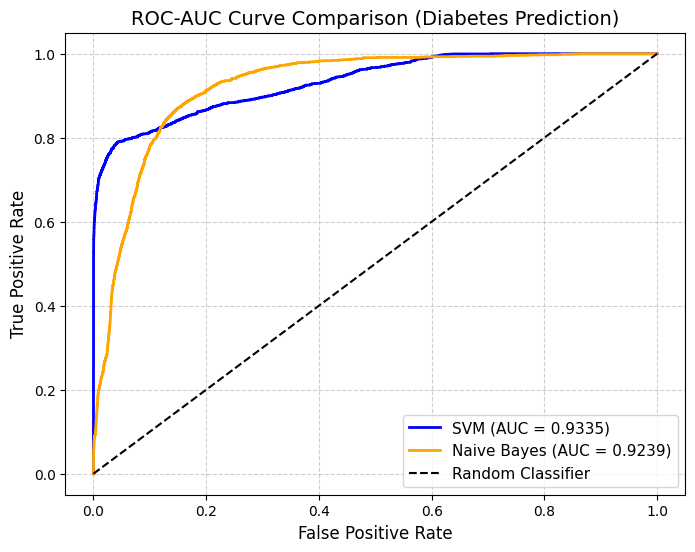

In [11]:
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)

fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
auc_nb = roc_auc_score(y_test, y_prob_nb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.4f})', color='blue', lw=2)
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.4f})', color='orange', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-AUC Curve Comparison (Diabetes Prediction)', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

results = pd.DataFrame({
    'Model': ['SVM (RBF)', 'Naive Bayes'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_nb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_nb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_nb)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_nb)
    ],
    'ROC-AUC': [auc_svm, auc_nb]
})

# Format to 4 decimal places
results.iloc[:, 1:] = results.iloc[:, 1:].round(4)
results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,SVM (RBF),0.9645,0.9723,0.5994,0.7416,0.9335
1,Naive Bayes,0.9046,0.4574,0.6594,0.5401,0.9239
